In [50]:
import matplotlib.pyplot as plt
import torch
import torch_geometric

# from graphMatching import *
from matplotlib.patches import ConnectionPatch
from model_tg import *
from networkx import read_edgelist
from scipy.io import loadmat
from utils import *

In [51]:
print(torch_geometric.__version__)

2.7.0


In [52]:
# !pip install torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cu121.html
# !pip install torch-geometric

In [53]:
data = "ACM_DBLP" # args.dataset

device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
train_features = {}
if (data == "ACM_DBLP"):
	train_set = ["ACM", "DBLP"]
	input_dim = 17
	b = np.load('data/ACM-DBLP.npz')
	train_features["ACM"] = [torch.from_numpy(b["x1"]).float()]
	train_features["DBLP"] = [torch.from_numpy(b["x2"]).float()]
	test_pairs = b['test_pairs'].astype(np.int32)
	NUM_HIDDEN_LAYERS = 12
	HIDDEN_DIM = [1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024,1024]
	output_feature_size = 1024
	lr = 0.0001
	epoch = 100
elif (data == "Douban Online_Offline"):
	a1, f1, a2, f2, test_pairs = load_douban()
	f1 = f1.A
	f2 = f2.A
	train_set = ["Online", "Offline"]
	input_dim = 538
	test_pairs = torch.tensor(np.array(test_pairs, dtype=int)) - 1
	test_pairs = test_pairs.numpy()
	train_features["Online"] = [torch.from_numpy(f1).float()]
	train_features["Offline"] = [torch.from_numpy(f2).float()]
	NUM_HIDDEN_LAYERS = 6
	HIDDEN_DIM = [512,512,512,512,512,512,512]
	output_feature_size = 512
	lr = 0.0001
	epoch = 100


In [54]:
b.files

['edge_index1', 'edge_index2', 'x1', 'x2', 'pos_pairs', 'test_pairs']

In [55]:
b["pos_pairs"]

array([[1177,  607],
       [2799, 8028],
       [3122, 3848],
       ...,
       [ 200, 3360],
       [7605, 5020],
       [6102,  570]], dtype=uint16)

In [56]:
print(train_features["ACM"][0].shape)
train_features["ACM"]

torch.Size([9872, 17])


[tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
         [54., 18., 12.,  ..., 11.,  0., 16.],
         [54., 61.,  9.,  ..., 10.,  0., 39.],
         ...,
         [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
         [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
         [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])]

In [57]:
train_features

{'ACM': [tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
          [54., 18., 12.,  ..., 11.,  0., 16.],
          [54., 61.,  9.,  ..., 10.,  0., 39.],
          ...,
          [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
          [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])],
 'DBLP': [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 4., 1.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 1., 0., 0.]])]}

In [58]:
train_features["ACM"][0]

tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
        [54., 18., 12.,  ..., 11.,  0., 16.],
        [54., 61.,  9.,  ..., 10.,  0., 39.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])

In [59]:
train_features[train_set[0]][0]

tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
        [54., 18., 12.,  ..., 11.,  0., 16.],
        [54., 61.,  9.,  ..., 10.,  0., 39.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]])

In [60]:
train_features["DBLP"][0]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 4., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [61]:
train_features[train_set[1]][0]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 4., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 0., 0.]])

In [62]:
""" temp = torch.from_numpy(b["x1"]).float() # G1, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x1"]).float() # G1, features\nprint(temp.shape)\ntemp '

In [63]:
""" temp = torch.from_numpy(b["x2"]).float() # G2, features
print(temp.shape)
temp """

' temp = torch.from_numpy(b["x2"]).float() # G2, features\nprint(temp.shape)\ntemp '

In [64]:
""" temp = b["test_pairs"]
print(temp.shape)
temp """

' temp = b["test_pairs"]\nprint(temp.shape)\ntemp '

In [65]:
test_pairs

array([[   0, 6829],
       [   2, 3102],
       [   3, 3584],
       ...,
       [9841, 3392],
       [9850,  306],
       [9868, 9011]], dtype=int32)

In [66]:
train_set

['ACM', 'DBLP']

In [68]:
print("Loading training datasets")

train_loader = {}
for dataset in train_set:
	train_loader[dataset] = [load_adj(dataset)]
train_loader


Loading training datasets


{'ACM': [tensor([[0., 1., 1.,  ..., 0., 0., 0.],
          [1., 0., 1.,  ..., 0., 0., 0.],
          [1., 1., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]])],
 'DBLP': [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]])]}

In [ ]:
train_loader.keys()

In [ ]:
train_loader

---

In [ ]:
adj_tensor = train_loader["ACM"][0]
print(adj_tensor.shape)
adj_tensor

In [ ]:
adj = coo_matrix(adj_tensor.numpy())
print(adj.shape)
adj

In [ ]:
adj_norm = preprocess_graph(adj)
print(len(adj_norm))
adj_norm

In [ ]:
adj_norm[0]

In [ ]:
adj_norm[1]

In [ ]:
adj_norm[2]

In [ ]:
adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
									torch.FloatTensor(adj_norm[1]),
									torch.Size(adj_norm[2])).to(device)
print(adj_norm.shape)
adj_norm

In [ ]:
type(adj_norm)

In [ ]:
adj_norm

In [ ]:
# Transform data

adj_coo = adj_norm.coalesce()  # Asegurar formato COO
edge_index = adj_coo.indices() # [2, E]
edge_weight = adj_coo.values().view(-1, 1) # Fron [E] to [E,1]
edge_attr = torch.cat([
	edge_weight.abs(),         # strength
	torch.sign(edge_weight),   # direction (+1, -1)
	edge_weight ** 2           # nonlinearity
], dim=1)            # [E,3]

features = train_features["ACM"][0]
print(edge_index.shape)
print(edge_index)

print(edge_weight.shape)
print(edge_weight)

print(edge_attr.shape)
print(edge_attr)

print(features.shape)
print(features)

In [ ]:
# Remove this
"""
# reduce dimensions of node features
for item in train_features:
	feat = train_features[item][0]
	reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
	train_features[item][0] = reduced_feat
train_features """

In [ ]:
# Remove this
# PCA

"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	pca = PCA(n_components=3)
	X_pca = pca.fit_transform(X_scaled)

	train_features[item][0] = torch.from_numpy(X_pca).float()
train_features """

In [ ]:
train_features

In [ ]:
# Remove this
# Scaler

""" from sklearn.preprocessing import StandardScaler

for item in train_features:
	feat = train_features[item][0]

	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(feat)

	train_features[item][0] = torch.from_numpy(X_scaled).float()
train_features """

---

In [ ]:
""" temp = train_loader["ACM"][0]
print(temp.shape)
temp """

In [ ]:
""" temp = train_loader["DBLP"][0]
print(temp.shape)
temp """

In [ ]:
train_loader

In [ ]:
train_set

In [ ]:
# Init

encoder = "GIN" # Change GIN, GINE
epoch = 100 # remove
output_feature_size = 16 # remove
flag = True # remove

if encoder == "GIN":
	input_dim = 17
	GAE = TGAE_GIN(NUM_HIDDEN_LAYERS,
				input_dim,
				HIDDEN_DIM,
				output_feature_size).to(device)
elif encoder == "GINE":
	input_dim = 17 # Change 3

	""" for item in train_features:
		feat = train_features[item][0]
		reduced_feat = feat[:, :3]  # Reduce to first 'input_dim' dimensions
		train_features[item][0] = reduced_feat """

	GAE = TGAE_GINE(NUM_HIDDEN_LAYERS,
			input_dim,
			HIDDEN_DIM,
			output_feature_size).to(device)

In [40]:
print("Generating training features")
print("Fitting model", encoder)
# fit_TGAE_subgraph(data, len(train_set) * (1 + 1), model, epoch, train_loader, train_features, device, lr,test_pairs)

# ---
no_samples = len(train_set) * (1 + 1)
# GAE = model
# ---

best_hitAtOne = 0
best_hitAtFive = 0
best_hitAtTen = 0
best_hitAtFifty = 0

optimizer = Adam(GAE.parameters(), lr=lr,weight_decay=5e-4)

loop_obj = tqdm(range(1, epoch + 1))
for step in loop_obj:
	loop_obj.set_description(f"Epoch: {step}")
	
	loss = 0
	
	for dataset in train_loader.keys():
		S = train_loader[dataset][0]
		initial_features = train_features[dataset]
		
		for i in range(len(train_loader[dataset])):
			adj_tensor = train_loader[dataset][i]
			adj = coo_matrix(adj_tensor.numpy())
			adj_norm = preprocess_graph(adj)
			pos_weight = float(adj.shape[0] * adj.shape[0] - adj.sum()) / adj.sum()
			norm = adj.shape[0] * adj.shape[0] / float((adj.shape[0] * adj.shape[0] - adj.sum()) * 2)

			adj_label = coo_matrix(S.numpy())
			adj_label = sparse_to_tuple(adj_label)

			adj_norm = torch.sparse.FloatTensor(torch.LongTensor(adj_norm[0].T),
												torch.FloatTensor(adj_norm[1]),
												torch.Size(adj_norm[2])).to(device)
			adj_label = torch.sparse.FloatTensor(torch.LongTensor(adj_label[0].T),
												torch.FloatTensor(adj_label[1]),
												torch.Size(adj_label[2])).to(device)

			initial_feature = initial_features[i].to(device)

			weight_mask = adj_label.to_dense().view(-1) == 1
			weight_tensor = torch.ones(weight_mask.size(0))
			weight_tensor[weight_mask] = pos_weight
			weight_tensor = weight_tensor.to(device)
			
			# Transform data
			# This seccion is modified to adapt to the new GAE implementation
			adj_coo = adj_norm.coalesce()  # Asegurar formato COO
			edge_index = adj_coo.indices().long() # [2, E]
			edge_weight = adj_coo.values().float().view(-1, 1) # [E,1]
			edge_attr = torch.cat([
				edge_weight.abs(),         # strength
				torch.sign(edge_weight),   # direction (+1, -1)
				edge_weight ** 2           # nonlinearity
			], dim=1) # [E,3]

			if flag: # Show data shapes only once
				print(edge_index.shape)
				print(edge_index)
				print()
				print(edge_weight.shape)
				print(edge_weight)
				print()
				print(edge_attr.shape)
				print(edge_attr)
				print()
				print(initial_feature.shape)
				print(initial_feature)
				flag = False

			if encoder == "GIN":
				z = GAE(initial_feature, edge_index)
			elif encoder == "GINE":
				z = GAE(initial_feature, edge_index, edge_weight)

			# z = GAE(initial_feature, adj_norm)
			A_pred = torch.sigmoid(torch.matmul(z, z.t()))
			loss += norm * F.binary_cross_entropy(A_pred.view(-1), adj_label.to_dense().view(-1),
														weight=weight_tensor)
			# loop_obj.set_postfix_str(f"Loss: {loss:.4f}")
	
	optimizer.zero_grad()
	loss = loss / no_samples
	loss.backward()
	optimizer.step()

	loop_obj.set_postfix_str(f"Loss: {loss:.4f}")

	# ---
	keys = list(train_loader.keys())
	S1 = train_loader[keys[0]][0]
	S2 = train_loader[keys[1]][0]
	
	adj_S1 = coo_matrix(S1.numpy())
	adj_norm_1 = preprocess_graph(adj_S1)
	adj_norm_1 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_1[0].T),
											torch.FloatTensor(adj_norm_1[1]),
											torch.Size(adj_norm_1[2])).to(device)
	adj_S2 = coo_matrix(S2.numpy())
	adj_norm_2 = preprocess_graph(adj_S2)
	adj_norm_2 = torch.sparse.FloatTensor(torch.LongTensor(adj_norm_2[0].T),
											torch.FloatTensor(adj_norm_2[1]),
											torch.Size(adj_norm_2[2])).to(device)
	""" if (data == "ACM_DBLP"):
		S1_feat = train_features["ACM"][0]
		S2_feat = train_features["DBLP"][0]
	elif (data == "Douban Online_Offline"):
		S1_feat = train_features["Online"][0]
		S2_feat = train_features["Offline"][0] """

	S1_feat = train_features[train_set[0]][0]
	S2_feat = train_features[train_set[1]][0]

	# ---
	adj_coo1 = adj_norm_1.coalesce()
	edge_index1 = adj_coo1.indices().long()
	edge_weight1 = adj_coo1.values().float().view(-1, 1)
	edge_attr1 = torch.cat([
		edge_weight1.abs(),         # strength
		torch.sign(edge_weight1),   # direction (+1, -1)
		edge_weight1 ** 2           # nonlinearity
	], dim=1) # [E,3]


	adj_coo2 = adj_norm_2.coalesce()
	edge_index2 = adj_coo2.indices().long()
	edge_weight2 = adj_coo2.values().float().view(-1, 1) # [E, 1] Change
	edge_attr2 = torch.cat([
		edge_weight2.abs(),         # strength
		torch.sign(edge_weight2),   # direction (+1, -1)
		edge_weight2 ** 2           # nonlinearity
	], dim=1) # [E,3]
	# ---

	# ---
	if encoder == "GIN":
		S1_emb = GAE(S1_feat.to(device), edge_index1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2).detach() # adj_norm_2).detach()
	elif encoder == "GINE":
		S1_emb = GAE(S1_feat.to(device), edge_index1, edge_weight1).detach() # adj_norm_1).detach()
		S2_emb = GAE(S2_feat.to(device), edge_index2, edge_weight2).detach() # adj_norm_2).detach()

	D = torch.cdist(S1_emb, S2_emb, 2) # Euclidean distance
	
	if (data == "ACM_DBLP"):
		test_idx = test_pairs[:, 0].astype(np.int32)
		labels = test_pairs[:, 1].astype(np.int32)
	elif (data == "Douban Online_Offline"):
		test_idx = test_pairs[0, :].astype(np.int32)
		labels = test_pairs[1, :].astype(np.int32)
	
	hitAtOne = 0
	hitAtFive = 0
	hitAtTen = 0
	hitAtFifty = 0
	hitAtHundred = 0
	
	# test
	for i in range(len(test_idx)):
		dist_list = D[test_idx[i]]
		# print(i, test_idx[i], dist_list)
		sorted_neighbors = torch.argsort(dist_list).cpu()
		label = labels[i]
		
		""" if i == 0:
			print(label, sorted_neighbors[0].item(), sorted_neighbors)
			# 6829 6829 tensor([6829, 3102,  601,  ..., 7878, 9701, 2044]) """
		
		for j in range(100):
			if (sorted_neighbors[j].item() == label):
				if (j == 0):
					hitAtOne += 1
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 4):
					hitAtFive += 1
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 9):
					hitAtTen += 1
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 49):
					hitAtFifty += 1
					hitAtHundred += 1
					break
				elif (j <= 100):
					hitAtHundred += 1
					break
	
	cur_hitAtOne = hitAtOne / len(test_idx)
	cur_hitAtFive = hitAtFive / len(test_idx)
	cur_hitAtTen = hitAtTen / len(test_idx)
	cur_hitAtFifty = hitAtFifty / len(test_idx)

	if(cur_hitAtOne > best_hitAtOne): best_hitAtOne = cur_hitAtOne
	if (cur_hitAtFive > best_hitAtFive): best_hitAtFive = cur_hitAtFive
	if (cur_hitAtTen > best_hitAtTen): best_hitAtTen = cur_hitAtTen
	if (cur_hitAtFifty > best_hitAtFifty): best_hitAtFifty = cur_hitAtFifty


print("The best results achieved:")
print("Hit@1: ", end="")
print(best_hitAtOne)
print("Hit@5: ", end="")
print(best_hitAtFive)
print("Hit@10: ", end="")
print(best_hitAtTen)
print("Hit@50: ", end="")
print(best_hitAtFifty)

torch.Size([2, 88994])
tensor([[   0,    0,    0,  ..., 9870, 9871, 9871],
        [   0,    1,    2,  ..., 9870, 4454, 9871]], device='cuda:0')

torch.Size([88994, 1])
tensor([[0.0050],
        [0.0054],
        [0.0061],
        ...,
        [0.2000],
        [0.5000],
        [0.5000]], device='cuda:0')

torch.Size([88994, 3])
tensor([[4.9505e-03, 1.0000e+00, 2.4507e-05],
        [5.3805e-03, 1.0000e+00, 2.8950e-05],
        [6.1240e-03, 1.0000e+00, 3.7504e-05],
        ...,
        [2.0000e-01, 1.0000e+00, 4.0000e-02],
        [5.0000e-01, 1.0000e+00, 2.5000e-01],
        [5.0000e-01, 1.0000e+00, 2.5000e-01]], device='cuda:0')

torch.Size([9872, 17])
tensor([[61., 42., 16.,  ..., 14.,  1., 22.],
        [54., 18., 12.,  ..., 11.,  0., 16.],
        [54., 61.,  9.,  ..., 10.,  0., 39.],
        ...,
        [ 0.,  0.,  0.,  ...,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  ...,  0.,  0.,  1.]], device='cuda:0')


Epoch: 100: 100%|██████████| 100/100 [06:28<00:00,  3.89s/it, Loss: 0.2124]

The best results achieved:
Hit@1: 0.599802371541502
Hit@5: 0.8015810276679842
Hit@10: 0.8535573122529644
Hit@50: 0.9138339920948617


In [41]:
# Get embeddings

print(S1_emb.shape)
S1_emb

torch.Size([9872, 16])


tensor([[-3.2367,  0.1017, -2.0170,  ...,  1.9097,  0.9060, -2.3555],
        [-3.0120,  0.5774, -0.6706,  ...,  1.3910, -0.2550, -2.9673],
        [-3.8742,  0.7896, -3.6159,  ...,  1.7467,  0.1083, -1.1734],
        ...,
        [-0.1780,  0.2927, -0.6356,  ...,  0.1906, -0.1114, -0.0700],
        [ 0.5776, -1.0096,  0.0094,  ...,  0.1907, -0.4851, -0.1542],
        [ 0.0650,  0.5774,  0.3353,  ...,  0.1141, -0.3346,  0.8684]],
       device='cuda:0')

In [42]:
print(S2_emb.shape)
S2_emb

torch.Size([9916, 16])


tensor([[ 0.6540, -0.2605, -0.0749,  ...,  0.3663, -0.6169,  0.4579],
        [-0.3890, -0.0919, -0.7858,  ..., -0.1475, -0.6318,  0.1648],
        [ 0.5206,  0.0914, -0.0538,  ..., -0.3628,  0.1965, -0.6213],
        ...,
        [ 0.5598, -0.3855, -0.0913,  ...,  0.7573, -0.5114,  0.4508],
        [ 0.1019, -0.0712,  0.1384,  ...,  0.5404, -0.2407, -0.0157],
        [-0.3252, -0.5361,  0.8128,  ...,  0.0348, -0.2362, -0.4988]],
       device='cuda:0')

In [43]:
# concat
S_emb_cat = torch.cat((S1_emb, S2_emb), dim=0).cpu().numpy()
S_emb_cat

array([[-3.236679  ,  0.10170326, -2.0169644 , ...,  1.9096619 ,
         0.90602976, -2.3554502 ],
       [-3.0119867 ,  0.5774127 , -0.67064196, ...,  1.3909671 ,
        -0.2550045 , -2.9673245 ],
       [-3.8741727 ,  0.7895857 , -3.615874  , ...,  1.7467079 ,
         0.10830126, -1.1733763 ],
       ...,
       [ 0.5597647 , -0.38548225, -0.09127752, ...,  0.75731874,
        -0.5113967 ,  0.45080236],
       [ 0.10194641, -0.07120231,  0.13842492, ...,  0.5403892 ,
        -0.2407389 , -0.01574953],
       [-0.32520708, -0.5360865 ,  0.8128408 , ...,  0.03475918,
        -0.23620462, -0.49877843]], dtype=float32)

##### Similarity analysis (KNN)

In [44]:
# Calculate distance matrix (KNN)
from sklearn.neighbors import NearestNeighbors
import pandas as pd

k = 1 # Change

df_x = S1_emb.cpu().numpy()
df_y = S2_emb.cpu().numpy()

knn = NearestNeighbors(n_neighbors=k, metric="euclidean")
knn.fit(df_y)
distances, indices = knn.kneighbors(df_x)
# print(indices)

result = []
for row in indices:
	# df_y_ = df_y.loc[row]
	result.append(row[0])
result

df_match = pd.DataFrame()
df_match["id"] = range(df_x.shape[0])
df_match

# aux = indices[:, top].flatten() # change
# df_y_ = df_y.loc[aux]
df_match["ids"] = result
df_match

,id,ids
0,0,6829
1,1,601
2,2,3102
3,3,3584
4,4,3744
...,...,...
9867,9867,3057
9868,9868,9011
9869,9869,3145
9870,9870,3456


In [45]:
print(test_pairs.shape)
""" for item in test_pairs:
    print(item) """
test_pairs

(5060, 2)


array([[   0, 6829],
       [   2, 3102],
       [   3, 3584],
       ...,
       [9841, 3392],
       [9850,  306],
       [9868, 9011]], dtype=int32)

In [46]:
# Get mask
mask = np.array([tuple(row) in map(tuple, test_pairs) for row in df_match.values])

df_match["mask"] = mask
df_match

,id,ids,mask
0,0,6829,True
1,1,601,False
2,2,3102,True
3,3,3584,True
4,4,3744,True
...,...,...,...
9867,9867,3057,False
9868,9868,9011,True
9869,9869,3145,False
9870,9870,3456,False


In [47]:
df_match[df_match["mask"] == True]

,id,ids,mask
0,0,6829,True
2,2,3102,True
3,3,3584,True
4,4,3744,True
5,5,685,True
...,...,...,...
9773,9773,3293,True
9810,9810,5387,True
9820,9820,8501,True
9850,9850,306,True


In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if S_emb_cat.shape[1] > 3:
	pca = PCA(n_components=3)
	S_emb_cat = pca.fit_transform(S_emb_cat)

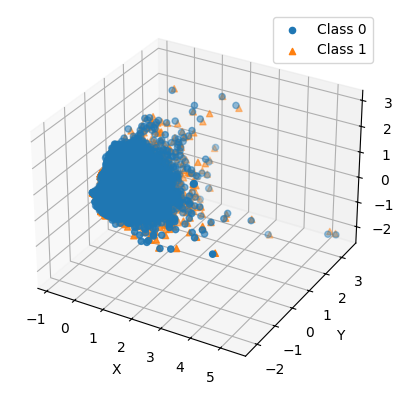

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Datos de ejemplo
X = S_emb_cat[:, 0]
Y = S_emb_cat[:, 1]
Z = S_emb_cat[:, 2]
labels = np.array([0] * S1_emb.shape[0] + [1] * S2_emb.shape[0])  # labels

fig = plt.figure()
ax = fig.add_subplot(projection="3d")

# Separar clases
ax.scatter(X[labels == 0], Y[labels == 0], Z[labels == 0], label="Class 0", marker="o")
ax.scatter(X[labels == 1], Y[labels == 1], Z[labels == 1], label="Class 1", marker="^")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()

plt.show()

##### Similarity analysis (Hungarian)

In [ ]:
print(D.shape)
D

Truth

In [ ]:
print(data)
print(test_pairs.shape)
print(test_pairs)

In [ ]:
if (data == "ACM_DBLP"):
	test_pairs_ = test_pairs
elif (data == "Douban Online_Offline"):
	test_pairs_ = test_pairs.T
	
truth = test_pairs_[test_pairs_[:, 1].argsort()]
print(truth.shape)
truth

In [ ]:
truth_ = test_pairs_[test_pairs_[:, 0].argsort()]
print(truth_.shape)
truth_

#### Option 0

In [ ]:
def hungarian(D):
	print("0")
	P = torch.zeros_like(D)
	matrix = D.tolist()
	m = Munkres()
	print("1")
	indexes = m.compute(matrix)
	print("2")
	total = 0
	for r, c in tqdm(indexes):
		print(r)
		P[r][c] = 1
		total += matrix[r][c]
	return P.t()

X = hungarian(D)
print(X.shape)
# online_offline: 215m
# acm_dblp: 2112m
X

In [ ]:
# save

X = X.cpu().numpy()
np.save("P_hungarian_ACM_DBLP", X)

In [ ]:
# load

X = np.load("P_hungarian.npy")
X

In [ ]:
option0 = []
m, n = X.shape
for i in range(m):
	for j in range(n):
		if X[i][j] == 1:
			option0.append([j, i]) # S, S_hat
option0 = np.array(option0)
print(len(option0))
option0

In [ ]:
matching = test_matching(truth, option0)
print(len(matching))
print(len(matching) / len(truth))
matching

#### Option 1

In [ ]:
total_cost, assignments = hungarian_algorithm(D.cpu())

In [ ]:
option1 = np.array(assignments)
option1 = option1[option1[:, 1].argsort()]
print(option1.shape)
option1

In [ ]:
option1_ = option1[:, [1, 0]]
option1_

In [ ]:
matching = test_match(truth, option1)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)

plot_match(G1, G2, matching)

#### Option 2

In [ ]:
import pygmtools as pygm

X = pygm.hungarian(D.cpu().numpy())
print(X.shape)
X

In [ ]:
option2 = matrix_to_edge(X)
option2

In [ ]:
option2_ = option2[:, [1, 0]]
option2_

In [ ]:
matching = test_match(truth, option2)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 3

In [ ]:
indices = []
for i in range(D.shape[0]):
	dist_list = D[i]
	sorted_neighbors = torch.argsort(dist_list).cpu()
	indices.append([i, sorted_neighbors[0]])

option3 = np.array(indices)
option3 = option3[option3[:, 1].argsort()]
print(option3.shape)
option3

In [ ]:
option3_ = option3[:, [1, 0]]
option3_

In [ ]:
matching = test_match(truth, option3)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 4

In [ ]:
X = greedy_match(D)
X = X.todense()
X = np.array(X)
print(X.shape)
print(X)

In [ ]:
option4 = matrix_to_edge(X)
option4

In [ ]:
option4_ = option4[:, [1, 0]]
option4_

In [ ]:
matching = test_match(truth, option4)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

#### Option 5

In [ ]:
D_ = complete_to_square(D.cpu(), pad_value=100.0)
print(D_.shape)
D_

In [ ]:
D.shape

In [ ]:
# X = get_match(torch.tensor(D_), device)
X = get_match(D, device)
print(X.shape)
X

In [ ]:
option5 = matrix_to_edge(X)
option5

In [ ]:
option5_ = option5[:, [1, 0]]
option5_

In [ ]:
matching = test_match(truth, option5_) # ACM_DBLP (option5_)
print(len(matching))
print(len(matching) / len(truth))
matching

In [ ]:
G1 = build_graph(adj_norm_1)
G2 = build_graph(adj_norm_2)
plot_match(G1, G2, matching)

---

In [ ]:
a = torch.tensor([[0.0,  0.0], [0.0, 1.0], [0.0,  2.0]])
print(a)
b = torch.tensor([[0.0, 1.0 ], [1.0,  1.0]])
print(b)
torch.cdist(a, b, p=2)

In [ ]:
a = torch.tensor([[4.01, 3.0, 2.0, 0.1, 4.0]])
print(a)
torch.argsort(a, dim=1)

In [ ]:
a = np.array([[9, 2, 3],
			  [4, 5, 6],
			  [7, 0, 5]])

a[a[:, 2].argsort()]